# Stress Level Classification Pipeline

Dataset: https://www.kaggle.com/datasets/mdsultanulislamovi/student-stress-monitoring-datasets

A complete **biomedical data analytics** pipeline for student stress-level classification.

| | |
|---|---|
| **Dataset** | Student Stress Factors — Kaggle (1,100 records, 20 clinical features) |
| **Target** | Classify stress level: `Low` · `Moderate` · `High` |
| **Pipeline** | StandardScaler → Random Forest (tuned via RandomizedSearchCV) |
| **Output** | Trained model · 6 evaluation plots · Feature importance |

---

## Setup — Imports & Plot Style

In [114]:
%matplotlib inline
import os, warnings
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import joblib
warnings.filterwarnings('ignore')

from sklearn.pipeline        import Pipeline
from sklearn.preprocessing   import StandardScaler, label_binarize
from sklearn.ensemble        import RandomForestClassifier
from sklearn.tree            import DecisionTreeClassifier
from sklearn.linear_model    import LogisticRegression
from sklearn.model_selection import (
    train_test_split, cross_val_score,
    StratifiedKFold, RandomizedSearchCV, learning_curve,
)
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    roc_auc_score, roc_curve, auc,
    precision_recall_curve, average_precision_score,
)

Libraries loaded.


## Configuration — Feature List & Label Map

In [115]:
FEATURE_COLS = [
    'anxiety_level', 'self_esteem', 'mental_health_history', 'depression',
    'headache', 'blood_pressure', 'sleep_quality', 'breathing_problem',
    'noise_level', 'living_conditions', 'safety', 'basic_needs',
    'academic_performance', 'study_load', 'teacher_student_relationship',
    'future_career_concerns', 'social_support', 'peer_pressure',
    'extracurricular_activities', 'bullying',
]
TARGET_COL = 'stress_level'
LABEL_MAP  = {0: 'Low', 1: 'Moderate', 2: 'High'}

FEATURE_LABELS = {
    'anxiety_level':                'Anxiety Level',
    'self_esteem':                  'Self Esteem',
    'mental_health_history':        'Mental Health History',
    'depression':                   'Depression Score',
    'headache':                     'Headache Frequency',
    'blood_pressure':               'Blood Pressure',
    'sleep_quality':                'Sleep Quality',
    'breathing_problem':            'Breathing Problems',
    'noise_level':                  'Noise / Environment',
    'living_conditions':            'Living Conditions',
    'safety':                       'Sense of Safety',
    'basic_needs':                  'Basic Needs Met',
    'academic_performance':         'Academic Performance',
    'study_load':                   'Study / Work Load',
    'teacher_student_relationship': 'Support from Authority',
    'future_career_concerns':       'Career Concerns',
    'social_support':               'Social Support',
    'peer_pressure':                'Peer Pressure',
    'extracurricular_activities':   'Extracurricular Activities',
    'bullying':                     'Bullying Experience',
}

DATA_PATH = os.path.join('data', 'StressLevelDataset.csv')
MODEL_DIR  = 'model'
os.makedirs(MODEL_DIR, exist_ok=True)

print(f'{len(FEATURE_COLS)} features defined.')

20 features defined.


---
## 1. Data Loading & Initial Exploration

Load the dataset and get an initial understanding of its structure, types, and content.

In [116]:
#loading the dataset
df = pd.read_csv('StressLevelDataset.csv')
print(f'Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns')
df.head()

Dataset shape: 1100 rows × 21 columns


,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,14,20,0,11,2,1,2,4,2,3,...,2,3,2,3,3,2,3,3,2,1
1,15,8,1,15,5,3,1,4,3,1,...,2,1,4,1,5,1,4,5,5,2
2,12,18,1,14,2,1,2,2,2,2,...,2,2,3,3,2,2,3,2,2,1
3,16,12,1,15,4,3,1,3,4,2,...,2,2,4,1,4,1,4,4,5,2
4,16,28,0,7,2,3,5,1,3,2,...,3,4,3,1,2,1,5,0,5,1


In [117]:
print('=== Data Types & Non-null Counts ===')
df.info()
print('\n=== Descriptive Statistics ===')
df[FEATURE_COLS].describe().round(2)

=== Data Types & Non-null Counts ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   anxiety_level                 1100 non-null   int64
 1   self_esteem                   1100 non-null   int64
 2   mental_health_history         1100 non-null   int64
 3   depression                    1100 non-null   int64
 4   headache                      1100 non-null   int64
 5   blood_pressure                1100 non-null   int64
 6   sleep_quality                 1100 non-null   int64
 7   breathing_problem             1100 non-null   int64
 8   noise_level                   1100 non-null   int64
 9   living_conditions             1100 non-null   int64
 10  safety                        1100 non-null   int64
 11  basic_needs                   1100 non-null   int64
 12  academic_performance          1100 non-null   int64
 

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,safety,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying
count,1100.00,1100.00,1100.00,1100.00,1100.00,1100.00,1100.00,1100.00,1100.00,1100.00,1100.00,1100.00,1100.00,1100.00,1100.00,1100.00,1100.00,1100.00,1100.00,1100.00
mean,11.06,17.78,0.49,12.56,2.51,2.18,2.66,2.75,2.65,2.52,2.74,2.77,2.77,2.62,2.65,2.65,1.88,2.73,2.77,2.62
std,6.12,8.94,0.50,7.73,1.41,0.83,1.55,1.40,1.33,1.12,1.41,1.43,1.41,1.32,1.38,1.53,1.05,1.43,1.42,1.53
min,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,6.00,11.00,0.00,6.00,1.00,1.00,1.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,1.00,1.00,2.00,2.00,1.00
50%,11.00,19.00,0.00,12.00,3.00,2.00,2.50,3.00,3.00,2.00,2.00,3.00,2.00,2.00,2.00,2.00,2.00,2.00,2.50,3.00
75%,16.00,26.00,1.00,19.00,3.00,3.00,4.00,4.00,3.00,3.00,4.00,4.00,4.00,3.00,4.00,4.00,3.00,4.00,4.00,4.00
max,21.00,30.00,1.00,27.00,5.00,3.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,3.00,5.00,5.00,5.00


---
## 2. Exploratory Data Analysis (EDA)

A systematic visual exploration of the dataset — distributions, relationships, and patterns that inform the modelling decisions.

### 2.1 Class Distribution

Check whether the three stress-level classes are **balanced**. Severe imbalance would require resampling or cost-sensitive learning.

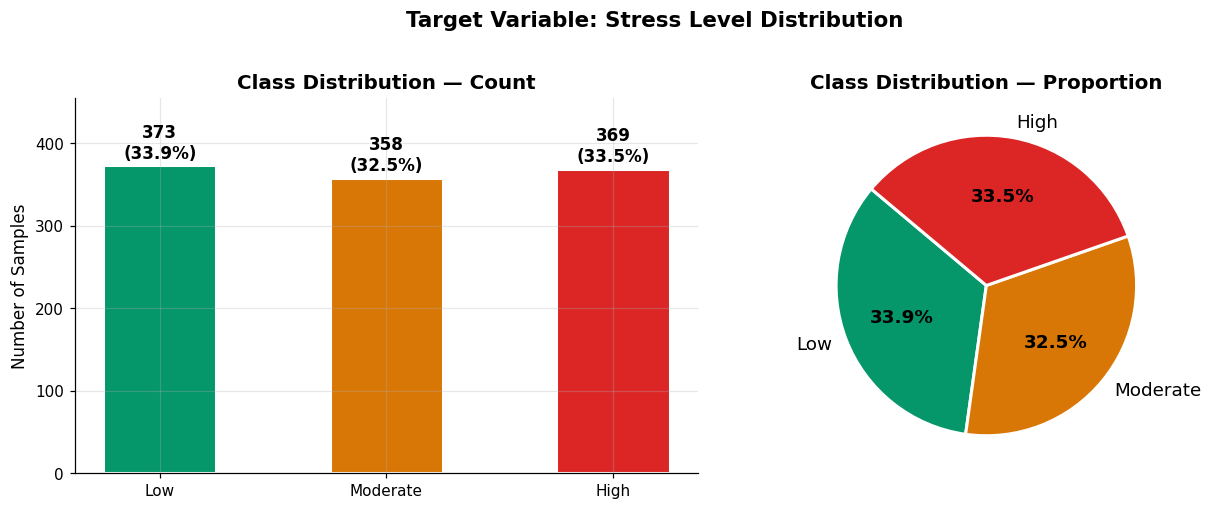

The dataset is well-balanced — no resampling required.


In [118]:
counts = df[TARGET_COL].value_counts().sort_index()
labels = [LABEL_MAP[i] for i in counts.index]
CLR = globals().get('CLR', {
    'Low': '#059669',
    'Moderate': '#d97706',
    'High': '#dc2626',
})
colors = [CLR[l] for l in labels]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Bar chart
bars = axes[0].bar(labels, counts.values, color=colors, width=0.5,
                   edgecolor='white', linewidth=2)
for bar, v in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 4,
                 f'{v}\n({v/len(df)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('Class Distribution — Count', fontweight='bold')
axes[0].set_ylabel('Number of Samples')
axes[0].set_ylim(0, counts.max() * 1.22)

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    counts.values, labels=labels, colors=colors,
    autopct='%1.1f%%', startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 12},
)
for at in autotexts:
    at.set_fontweight('bold')
axes[1].set_title('Class Distribution — Proportion', fontweight='bold')

plt.suptitle('Target Variable: Stress Level Distribution', fontsize=14,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('The dataset is well-balanced — no resampling required.')

### 2.2 Missing Value Analysis

Missing values can silently bias a model. We visualise their presence before any imputation.

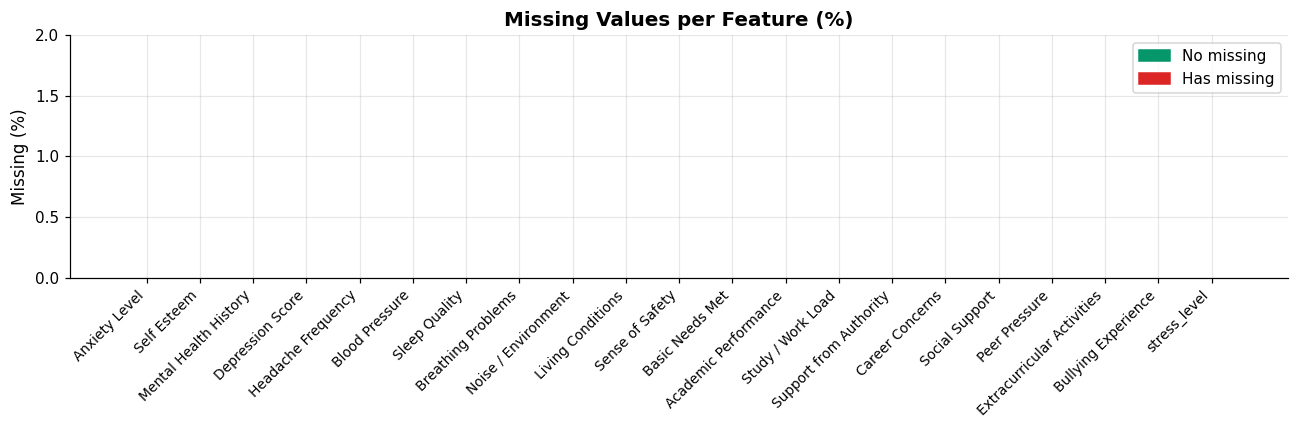

No missing values detected — dataset is complete.


In [119]:
missing = df[FEATURE_COLS + [TARGET_COL]].isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

fig, ax = plt.subplots(figsize=(12, 4))
bar_colors = ['#dc2626' if p > 0 else '#059669' for p in missing_pct.values]
bars = ax.bar(
    [FEATURE_LABELS.get(c, c) for c in missing_pct.index],
    missing_pct.values, color=bar_colors, edgecolor='white'
)
ax.set_title('Missing Values per Feature (%)', fontweight='bold')
ax.set_ylabel('Missing (%)')
ax.set_ylim(0, max(missing_pct.max() + 1, 2))
plt.xticks(rotation=45, ha='right', fontsize=9)
ax.axhline(0, color='gray', linewidth=0.5)

# Legend
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#059669', label='No missing'),
    Patch(color='#dc2626', label='Has missing'),
], fontsize=10)
plt.tight_layout()
plt.show()

if missing.sum() == 0:
    print('No missing values detected — dataset is complete.')
else:
    print(missing[missing > 0].to_string())

### 2.3 Feature Distributions (All 20 Features)

Histograms reveal the **shape, range, and skewness** of each feature. Binary features (0/1) will show two-bar distributions; ordinal features (0–10) should show a spread.

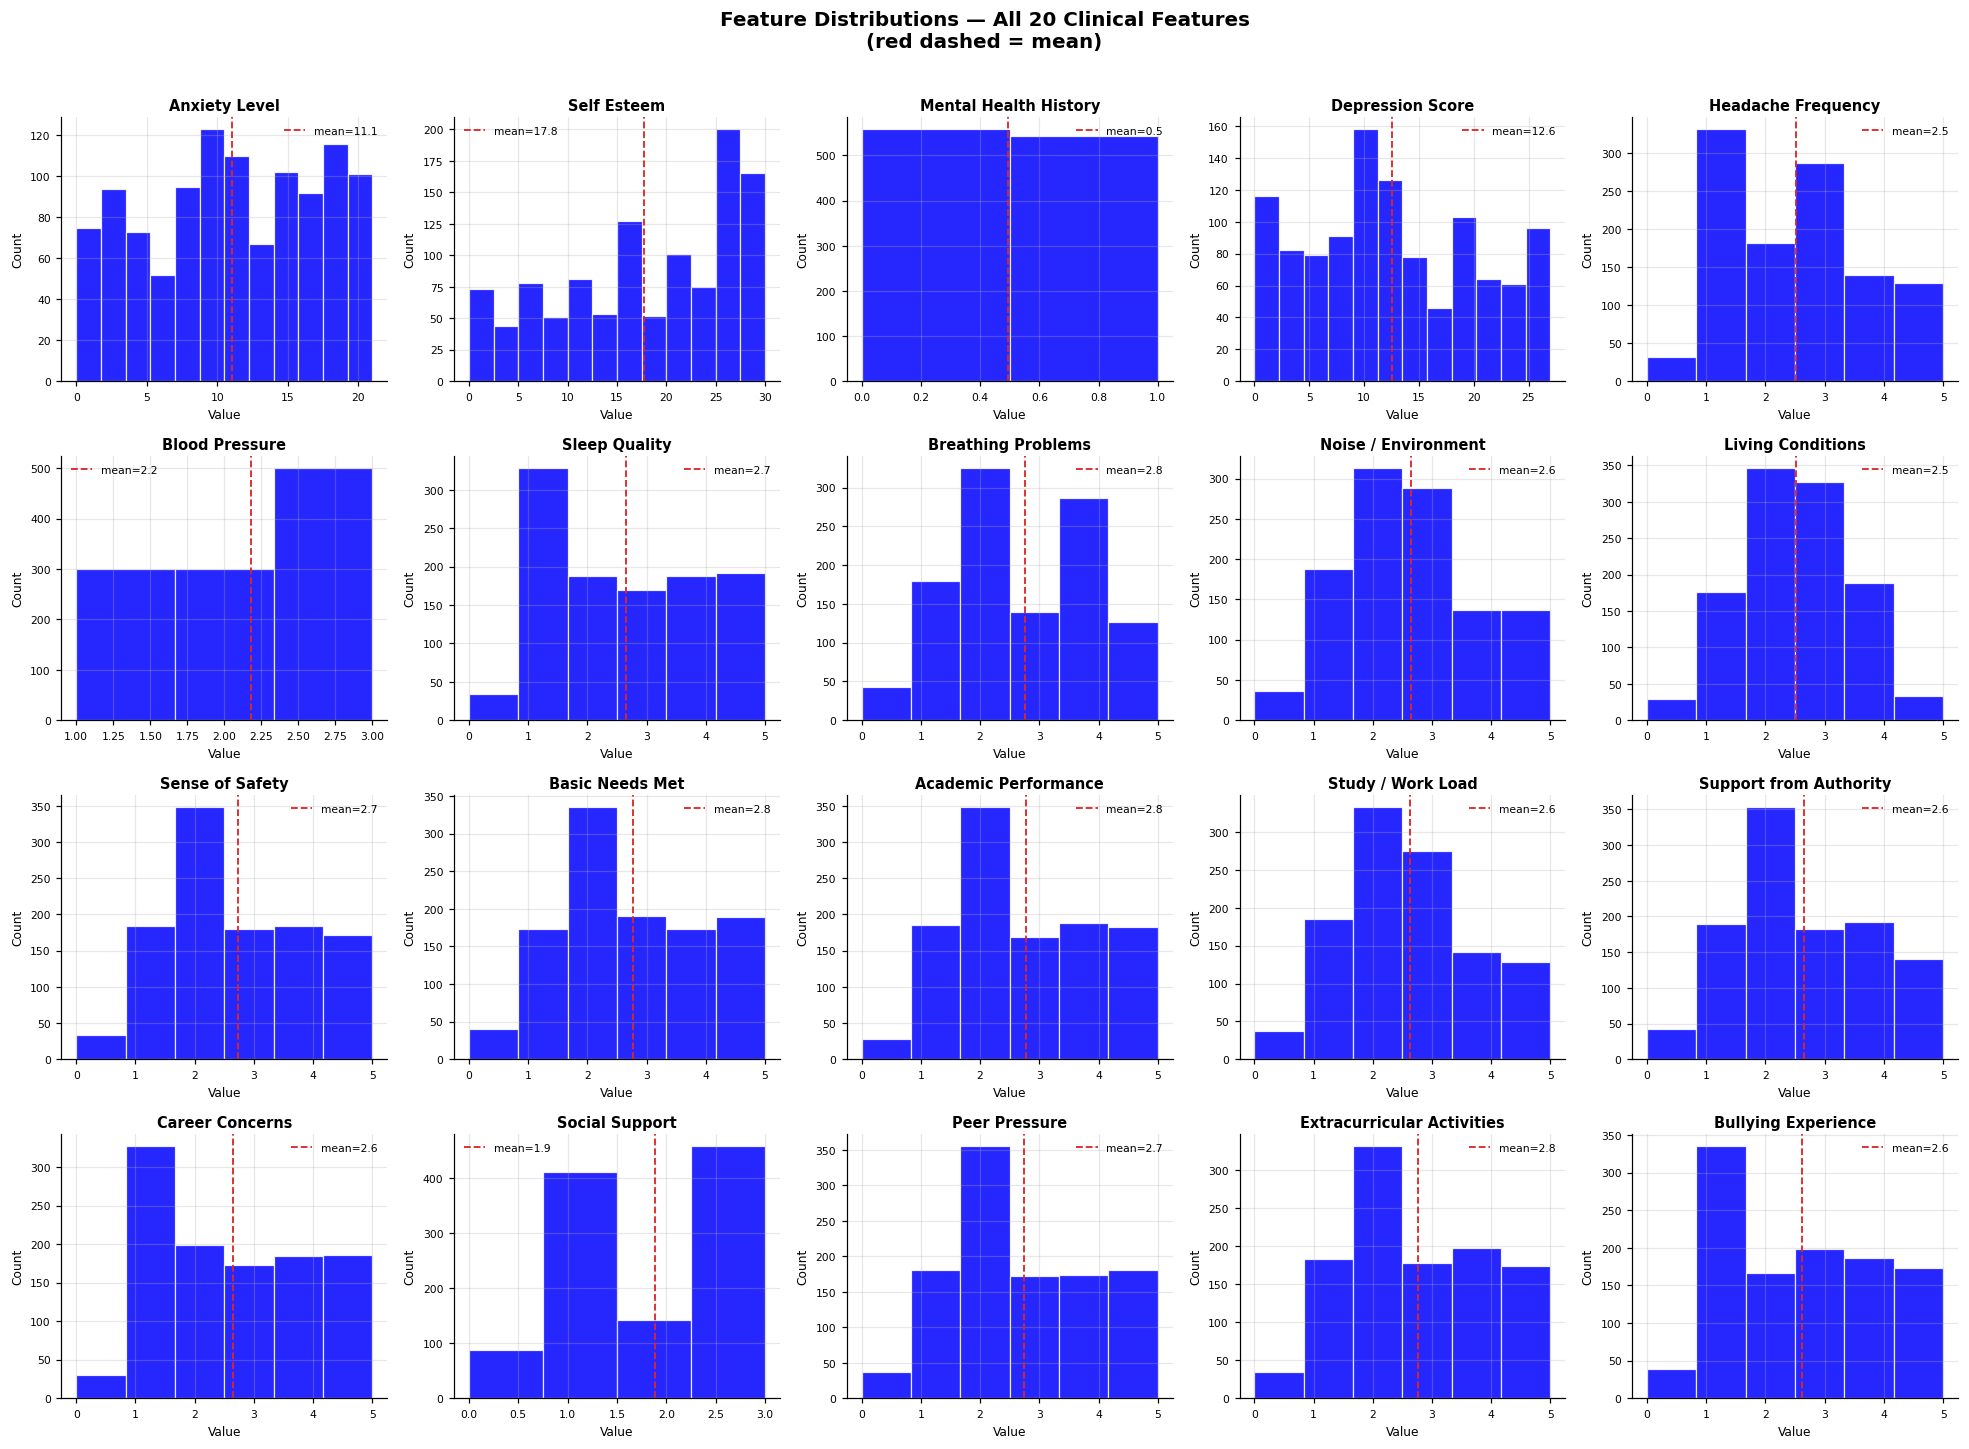

In [120]:
fig, axes = plt.subplots(4, 5, figsize=(18, 13))
axes = axes.flatten()

for i, col in enumerate(FEATURE_COLS):
    ax = axes[i]
    n_unique = df[col].nunique()
    bins = min(n_unique, 12)
    ax.hist(df[col], bins=bins, color="blue", edgecolor='white',
            linewidth=0.8, alpha=0.85)
    ax.set_title(FEATURE_LABELS[col], fontsize=9.5, fontweight='bold', pad=4)
    ax.set_xlabel('Value', fontsize=8)
    ax.set_ylabel('Count', fontsize=8)
    ax.tick_params(labelsize=7)
    # Add mean line
    mean_val = df[col].mean()
    ax.axvline(mean_val, color='#dc2626', linestyle='--', linewidth=1.2,
               label=f'mean={mean_val:.1f}')
    ax.legend(fontsize=7, frameon=False)

plt.suptitle('Feature Distributions — All 20 Clinical Features\n(red dashed = mean)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 2.4 Feature Distributions by Stress Level

**Box plots** show how each feature's distribution shifts across stress classes — the most direct way to see which features are **discriminative**.

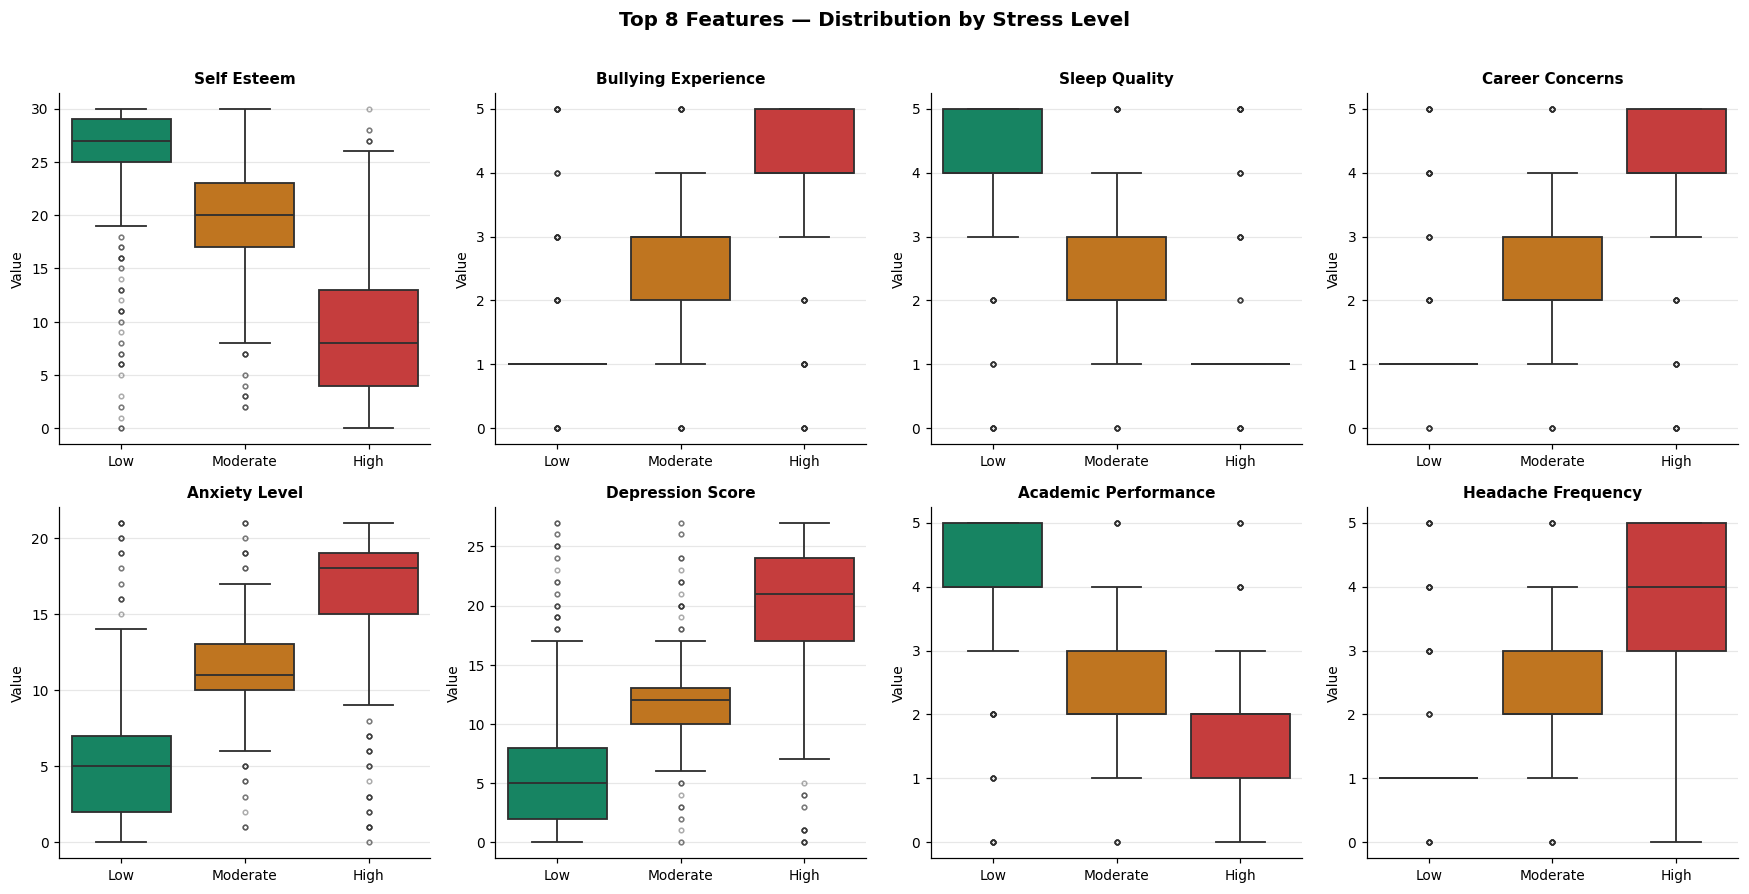

In [121]:
# Top 8 features by absolute correlation with target
corr_with_target = df[FEATURE_COLS + [TARGET_COL]].corr()[TARGET_COL].drop(TARGET_COL)
top8 = corr_with_target.abs().sort_values(ascending=False).head(8).index.tolist()

df_plot = df.copy()
df_plot['Stress Level'] = df_plot[TARGET_COL].map(LABEL_MAP)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(top8):
    ax = axes[i]
    sns.boxplot(
        data=df_plot, x='Stress Level', y=col,
        order=['Low', 'Moderate', 'High'],
        palette=CLR, ax=ax,
        flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.4},
        linewidth=1.2,
    )
    ax.set_title(FEATURE_LABELS[col], fontweight='bold', fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('Value', fontsize=9)
    ax.tick_params(labelsize=9)

plt.suptitle('Top 8 Features — Distribution by Stress Level',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 2.5 Violin Plots — Top 4 Most Discriminative Features

Violin plots combine a box plot with a **kernel density estimate** — showing the full shape of the distribution, not just quartiles.

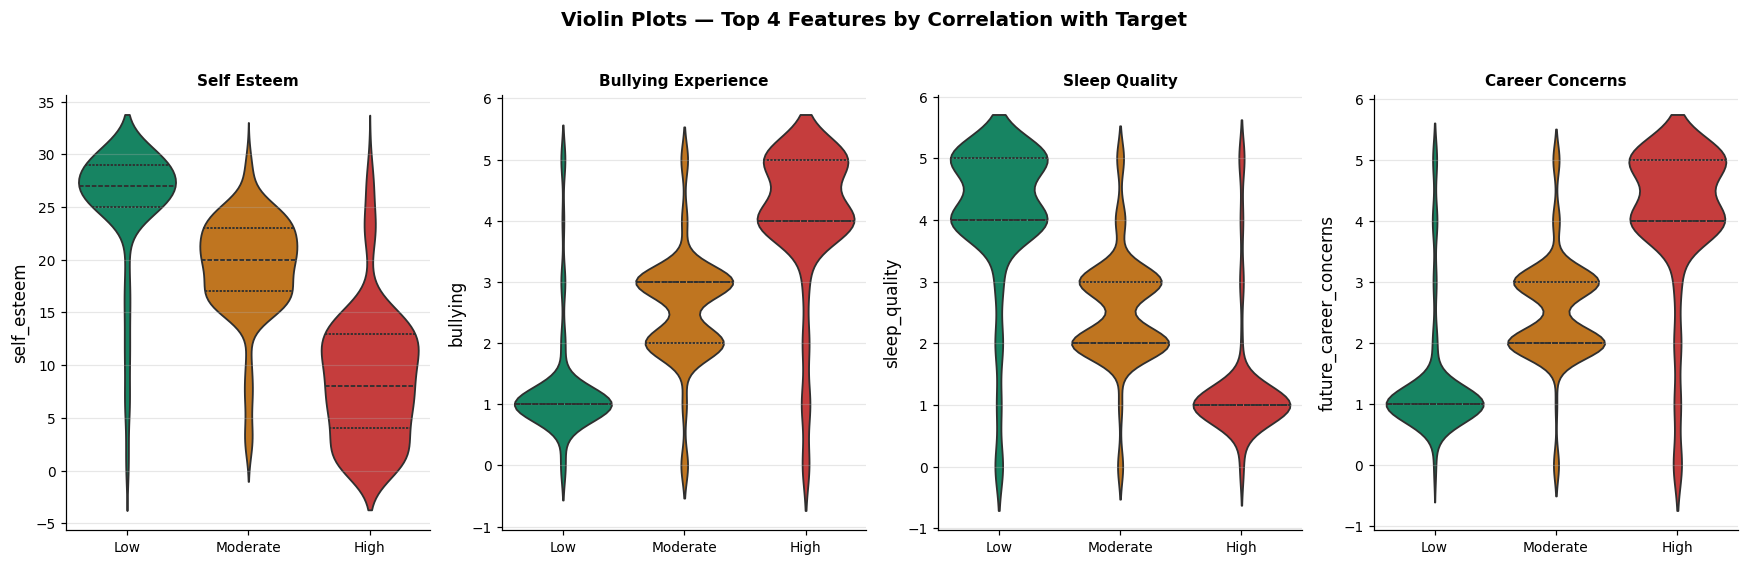

In [122]:
top4 = corr_with_target.abs().sort_values(ascending=False).head(4).index.tolist()

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for i, col in enumerate(top4):
    ax = axes[i]
    sns.violinplot(
        data=df_plot, x='Stress Level', y=col,
        order=['Low', 'Moderate', 'High'],
        palette=CLR, ax=ax, inner='quartile',
        linewidth=1.2,
    )
    ax.set_title(FEATURE_LABELS[col], fontweight='bold', fontsize=10)
    ax.set_xlabel('')
    ax.tick_params(labelsize=9)

plt.suptitle('Violin Plots — Top 4 Features by Correlation with Target',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 2.6 Feature Correlation Heatmap

A **Pearson correlation matrix** across all features. Highly correlated feature pairs (|r| > 0.7) may indicate redundancy — useful context for feature selection.

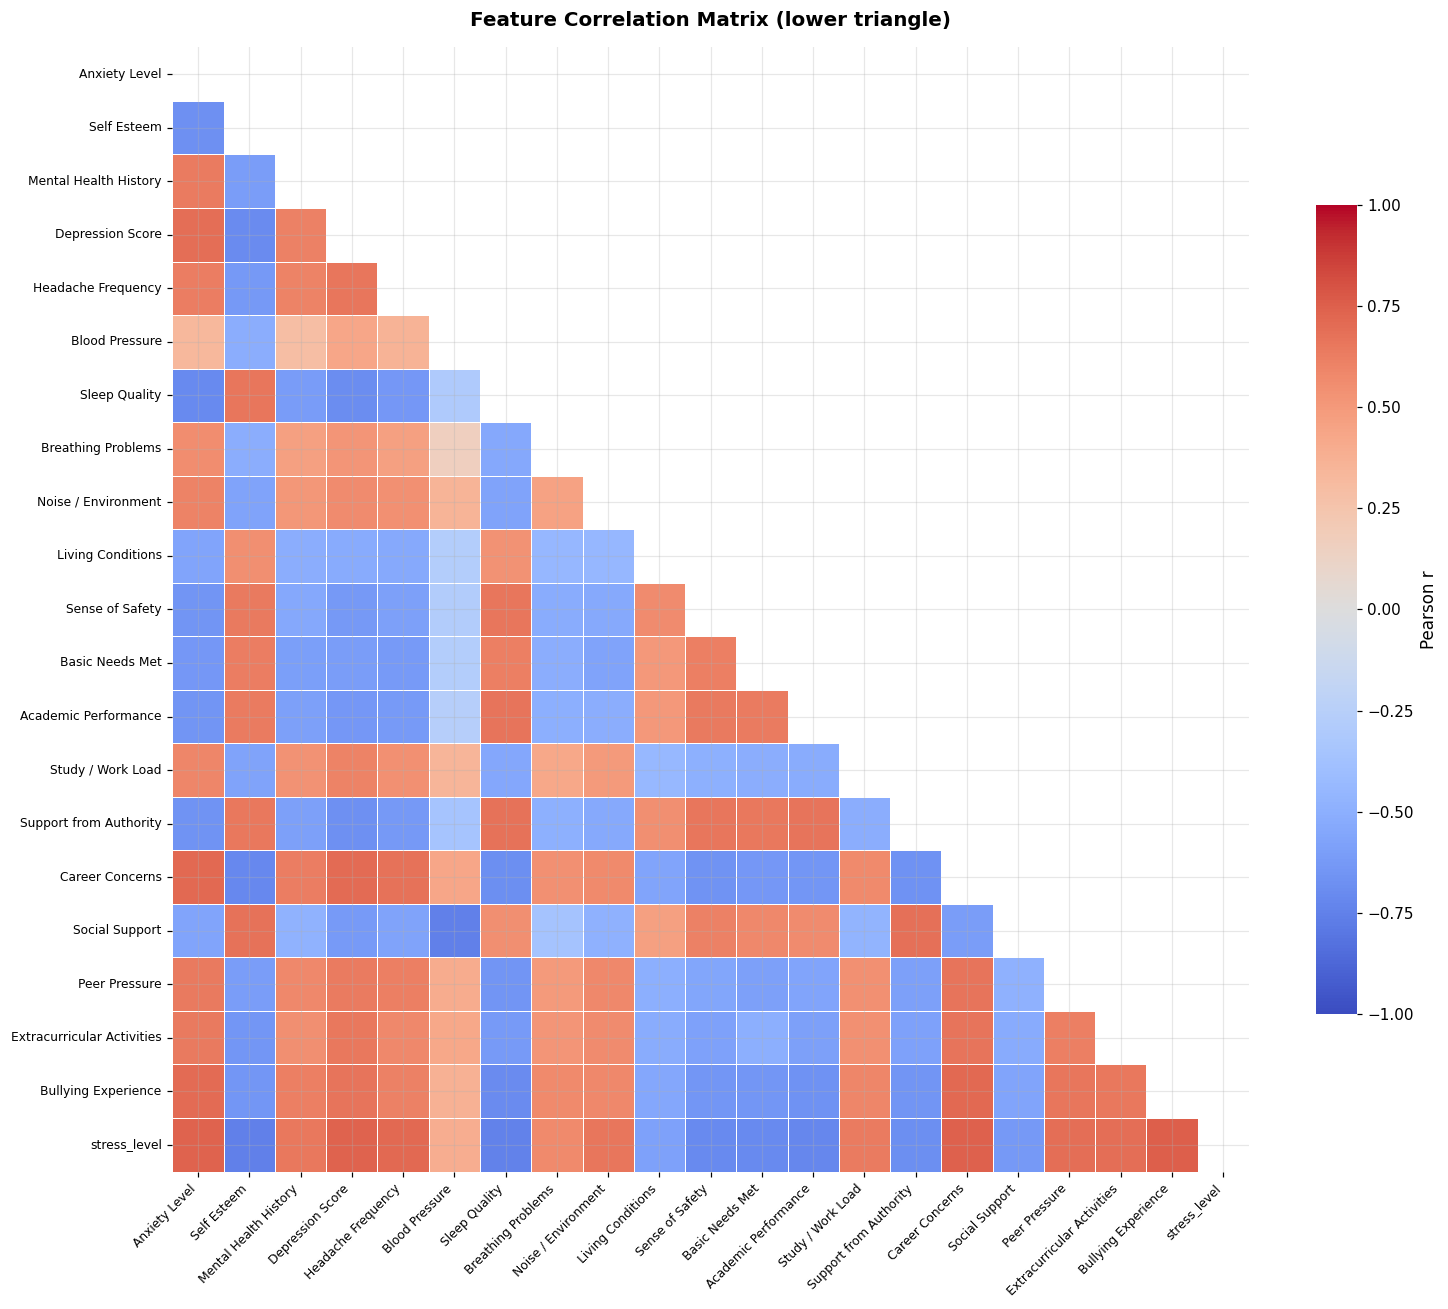

In [123]:
corr = df[FEATURE_COLS + [TARGET_COL]].corr()
tick_labels = [FEATURE_LABELS.get(c, c) for c in corr.columns]

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))   # upper triangle only
sns.heatmap(
    corr, mask=mask, cmap='coolwarm', center=0, vmin=-1, vmax=1,
    linewidths=0.4, ax=ax, annot=False,
    xticklabels=tick_labels, yticklabels=tick_labels,
    cbar_kws={'shrink': 0.72, 'label': 'Pearson r'},
)
ax.set_title('Feature Correlation Matrix (lower triangle)',
             fontsize=13, fontweight='bold', pad=14)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

### 2.7 Feature Correlation with Target Variable

Ranking features by their **absolute correlation with stress_level** identifies the strongest predictors and informs which features the model is likely to rely on most.

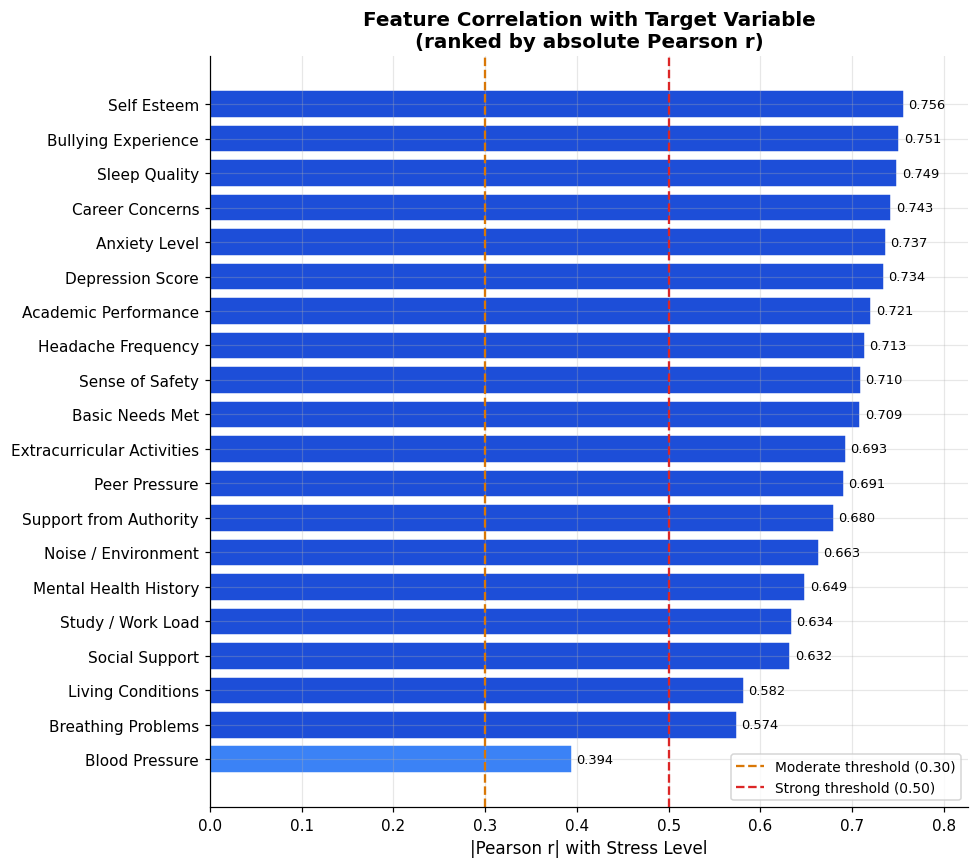

Top 5 predictors:
  Self Esteem                     r = -0.756  (negative)
  Bullying Experience             r = +0.751  (positive)
  Sleep Quality                   r = -0.749  (negative)
  Career Concerns                 r = +0.743  (positive)
  Anxiety Level                   r = +0.737  (positive)


In [124]:
target_corr = corr[TARGET_COL].drop(TARGET_COL)
target_corr_abs = target_corr.abs().sort_values(ascending=False)
feat_names = [FEATURE_LABELS.get(i, i) for i in target_corr_abs.index]

bar_colors = [
    '#1d4ed8' if v > 0.5 else
    '#3b82f6' if v > 0.3 else
    '#93c5fd'
    for v in target_corr_abs.values
]

fig, ax = plt.subplots(figsize=(9, 8))
bars = ax.barh(feat_names[::-1], target_corr_abs.values[::-1],
               color=bar_colors[::-1], edgecolor='white')

for bar, val in zip(bars, target_corr_abs.values[::-1]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8.5)

ax.axvline(0.30, color='#d97706', linestyle='--', lw=1.5,
           label='Moderate threshold (0.30)')
ax.axvline(0.50, color='#dc2626', linestyle='--', lw=1.5,
           label='Strong threshold (0.50)')
ax.set_xlabel('|Pearson r| with Stress Level', fontsize=11)
ax.set_title('Feature Correlation with Target Variable\n(ranked by absolute Pearson r)',
             fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(0, target_corr_abs.max() + 0.07)
plt.tight_layout()
plt.show()

print('Top 5 predictors:')
for feat, val in zip(target_corr_abs.index[:5], target_corr_abs.values[:5]):
    direction = 'positive' if target_corr[feat] > 0 else 'negative'
    print(f'  {FEATURE_LABELS[feat]:30s}  r = {target_corr[feat]:+.3f}  ({direction})')

### 2.8 Mean Feature Values by Stress Class

A **class-conditional heatmap** shows the average value of every feature within each stress class — a compact view of what makes each class distinct.

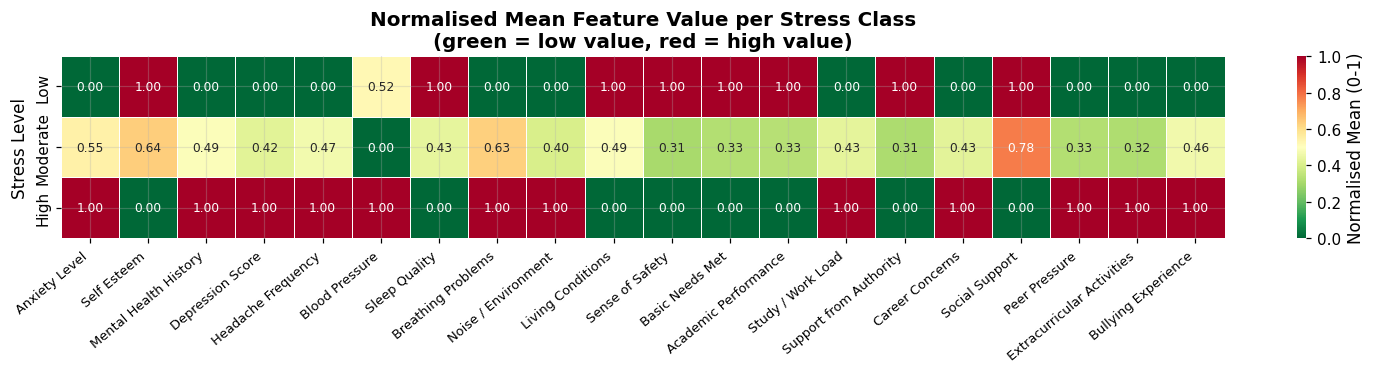

In [125]:
class_means = df.groupby(TARGET_COL)[FEATURE_COLS].mean()
class_means.index = [LABEL_MAP[i] for i in class_means.index]

# Normalise each column 0-1 so features are on the same scale
class_means_norm = (class_means - class_means.min()) / (class_means.max() - class_means.min())
class_means_norm.columns = [FEATURE_LABELS[c] for c in class_means_norm.columns]

fig, ax = plt.subplots(figsize=(14, 3.5))
sns.heatmap(
    class_means_norm, cmap='RdYlGn_r', annot=True, fmt='.2f',
    linewidths=0.5, ax=ax, cbar_kws={'label': 'Normalised Mean (0-1)'},
    annot_kws={'size': 8},
)
ax.set_title('Normalised Mean Feature Value per Stress Class\n'
             '(green = low value, red = high value)',
             fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Stress Level', fontsize=11)
plt.xticks(rotation=40, ha='right', fontsize=8.5)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

---
## 3. Preprocessing

Steps applied before modelling:
1. Drop rows missing any feature or label
2. Coerce all features to numeric (handle any stray strings)
3. Fill remaining NaN with 0 and clip negatives — ordinal features have no valid negative range

In [126]:
def preprocess(df):
    df = df.copy()
    before = len(df)
    df.dropna(subset=FEATURE_COLS + [TARGET_COL], inplace=True)
    for col in FEATURE_COLS:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).clip(lower=0)
    print(f'Rows before: {before:,}  |  after: {len(df):,}  |  dropped: {before - len(df)}')
    return df

df_clean = preprocess(df)
print(f'Class balance after preprocessing:')
print(df_clean[TARGET_COL].value_counts().sort_index().rename(LABEL_MAP).to_string())

Rows before: 1,100  |  after: 1,100  |  dropped: 0
Class balance after preprocessing:
stress_level
Low         373
Moderate    358
High        369


---
## 4. Train / Test Split

**Stratified split** (80/20) — ensures each subset contains the same class proportions as the full dataset.

Train: 880 samples   Test: 220 samples


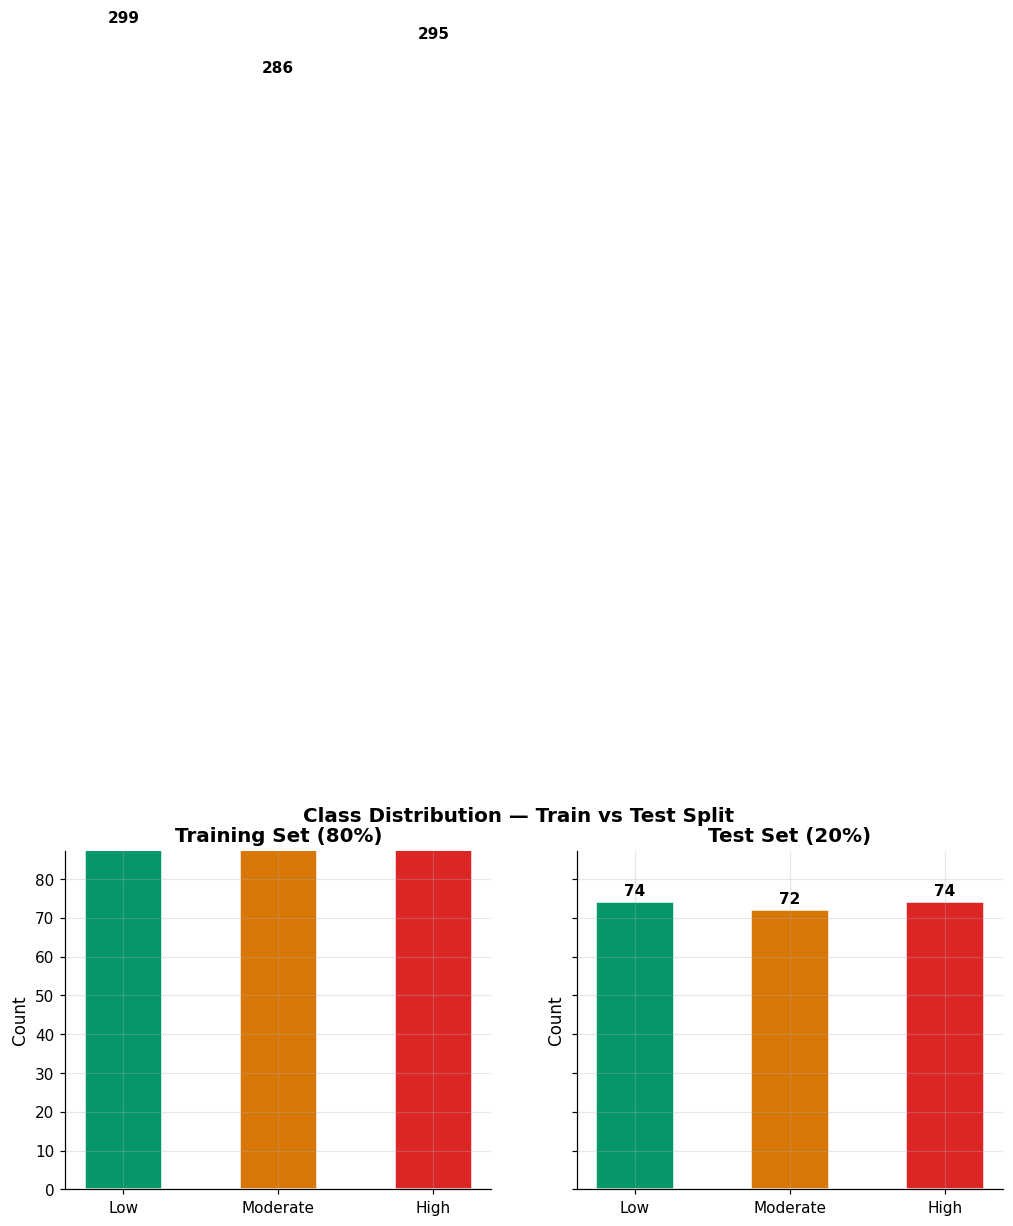

In [127]:
X = df_clean[FEATURE_COLS]
y = df_clean[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {len(X_train):,} samples   Test: {len(X_test):,} samples')

# Visualise class balance in each split
train_counts = y_train.value_counts().sort_index().rename(LABEL_MAP)
test_counts  = y_test.value_counts().sort_index().rename(LABEL_MAP)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, counts, title in zip(axes,
                              [train_counts, test_counts],
                              ['Training Set (80%)', 'Test Set (20%)']):
    bars = ax.bar(counts.index, counts.values,
                  color=[CLR[l] for l in counts.index],
                  edgecolor='white', width=0.5)
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{v}', ha='center', va='bottom', fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Count')
    ax.set_ylim(0, counts.max() * 1.18)

plt.suptitle('Class Distribution — Train vs Test Split', fontsize=13,
             fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Feature Scaling (StandardScaler)

`StandardScaler` transforms each feature to zero mean and unit variance. While tree-based models are scale-invariant, scaling is required for **Logistic Regression** and ensures a fair model comparison. All models are wrapped in a `sklearn.Pipeline` so the scaler is fitted only on training data — preventing data leakage.

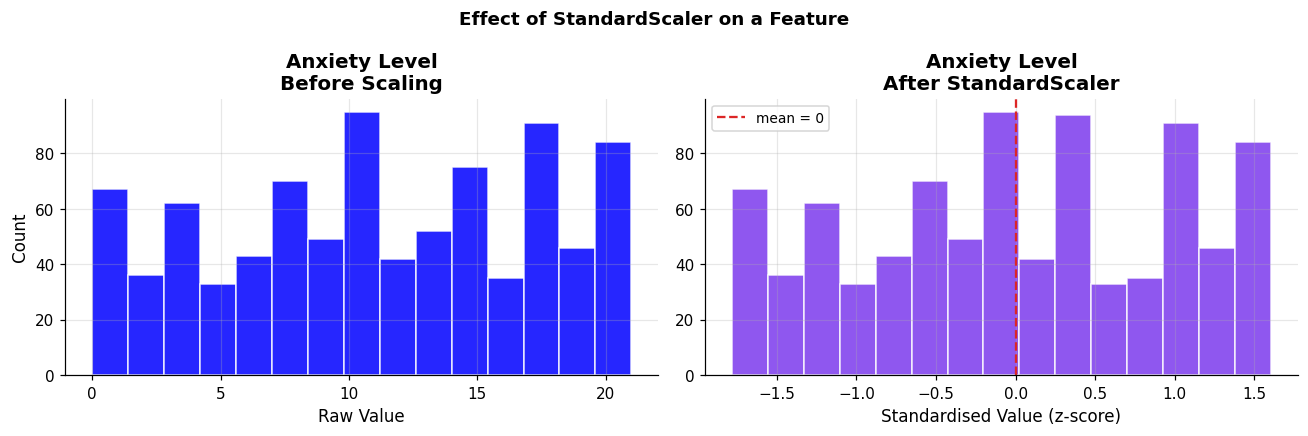

Before — mean: 11.05  std: 6.20
After  — mean: 0.00  std: 1.00


In [128]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), columns=FEATURE_COLS
)

# Compare one feature before/after scaling
demo_feat = 'anxiety_level'
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(X_train[demo_feat], bins=15, color="BLUE", edgecolor='white', alpha=0.85)
axes[0].set_title(f'{FEATURE_LABELS[demo_feat]}\nBefore Scaling', fontweight='bold')
axes[0].set_xlabel('Raw Value')
axes[0].set_ylabel('Count')

axes[1].hist(X_train_scaled[demo_feat], bins=15, color='#7c3aed',
             edgecolor='white', alpha=0.85)
axes[1].set_title(f'{FEATURE_LABELS[demo_feat]}\nAfter StandardScaler', fontweight='bold')
axes[1].set_xlabel('Standardised Value (z-score)')
axes[1].axvline(0, color='#dc2626', linestyle='--', lw=1.5, label='mean = 0')
axes[1].legend(fontsize=9)

plt.suptitle('Effect of StandardScaler on a Feature', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Before — mean: {X_train[demo_feat].mean():.2f}  std: {X_train[demo_feat].std():.2f}')
print(f'After  — mean: {X_train_scaled[demo_feat].mean():.2f}  std: {X_train_scaled[demo_feat].std():.2f}')

---
## 6. Model Comparison — 5-Fold Stratified CV

Three classifiers are evaluated under identical conditions:
- Each is wrapped in a **`StandardScaler → Classifier` Pipeline**
- Evaluated with **Stratified 5-Fold Cross-Validation** (preserves class proportions per fold)
- `class_weight='balanced'` applied to account for any residual imbalance

In [129]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

candidates = {
    'Logistic\nRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    LogisticRegression(max_iter=1000, random_state=42,
                                      class_weight='balanced')),
    ]),
    'Decision\nTree': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    DecisionTreeClassifier(max_depth=8, random_state=42,
                                          class_weight='balanced')),
    ]),
    'Random\nForest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    RandomForestClassifier(n_estimators=100, random_state=42,
                                          class_weight='balanced', n_jobs=-1)),
    ]),
}

results = {}
print(f'{"Model":<22} {"CV Acc":>8}  {"+/-":>6}  {"Test Acc":>9}')
print('-' * 50)
for name, pipe in candidates.items():
    scores   = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='accuracy')
    pipe.fit(X_train, y_train)
    test_acc = accuracy_score(y_test, pipe.predict(X_test))
    results[name] = {'cv': scores, 'test_acc': test_acc, 'pipe': pipe}
    label = name.replace('\n', ' ')
    print(f'{label:<22} {scores.mean():.3f}    {scores.std():.3f}    {test_acc:.3f}')

Model                    CV Acc     +/-   Test Acc
--------------------------------------------------
Logistic Regression    0.877    0.028    0.886
Decision Tree          0.873    0.034    0.868
Random Forest          0.875    0.032    0.877


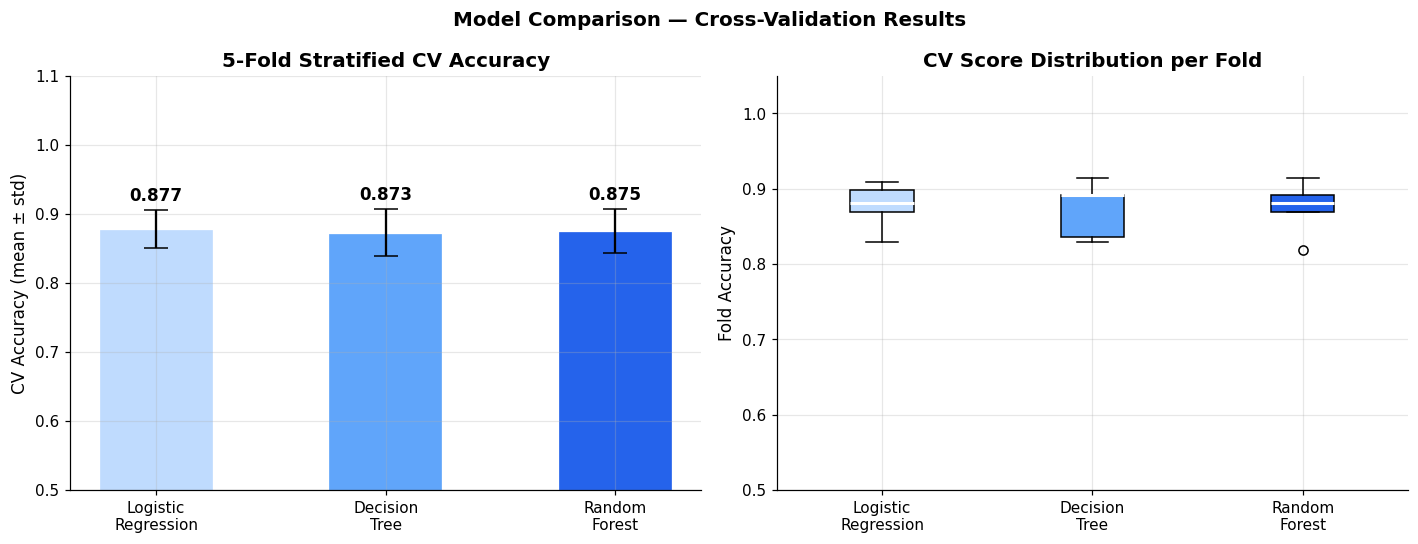

In [130]:
names  = list(results.keys())
means  = [results[n]['cv'].mean() for n in names]
stds   = [results[n]['cv'].std()  for n in names]
tests  = [results[n]['test_acc']  for n in names]
colors = ['#bfdbfe', '#60a5fa', '#2563eb']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# CV accuracy with error bars
bars = axes[0].bar(names, means, yerr=stds, capsize=8, color=colors,
                   edgecolor='white', linewidth=1.5, width=0.5)
for bar, mean, std in zip(bars, means, stds):
    axes[0].text(bar.get_x() + bar.get_width()/2, mean + std + 0.008,
                 f'{mean:.3f}', ha='center', va='bottom',
                 fontsize=11, fontweight='bold')
axes[0].set_ylim(0.5, 1.1)
axes[0].set_ylabel('CV Accuracy (mean ± std)', fontsize=11)
axes[0].set_title('5-Fold Stratified CV Accuracy', fontweight='bold')

# CV score distributions (box plot)
cv_scores = [results[n]['cv'] for n in names]
bp = axes[1].boxplot(cv_scores, labels=names, patch_artist=True,
                     medianprops={'color': 'white', 'linewidth': 2})
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
axes[1].set_ylim(0.5, 1.05)
axes[1].set_ylabel('Fold Accuracy', fontsize=11)
axes[1].set_title('CV Score Distribution per Fold', fontweight='bold')

plt.suptitle('Model Comparison — Cross-Validation Results',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 6.1 Learning Curves

Learning curves show how model accuracy evolves as training data grows. A **large gap** between training and validation curves signals overfitting; **both curves plateauing at a low value** signals underfitting.

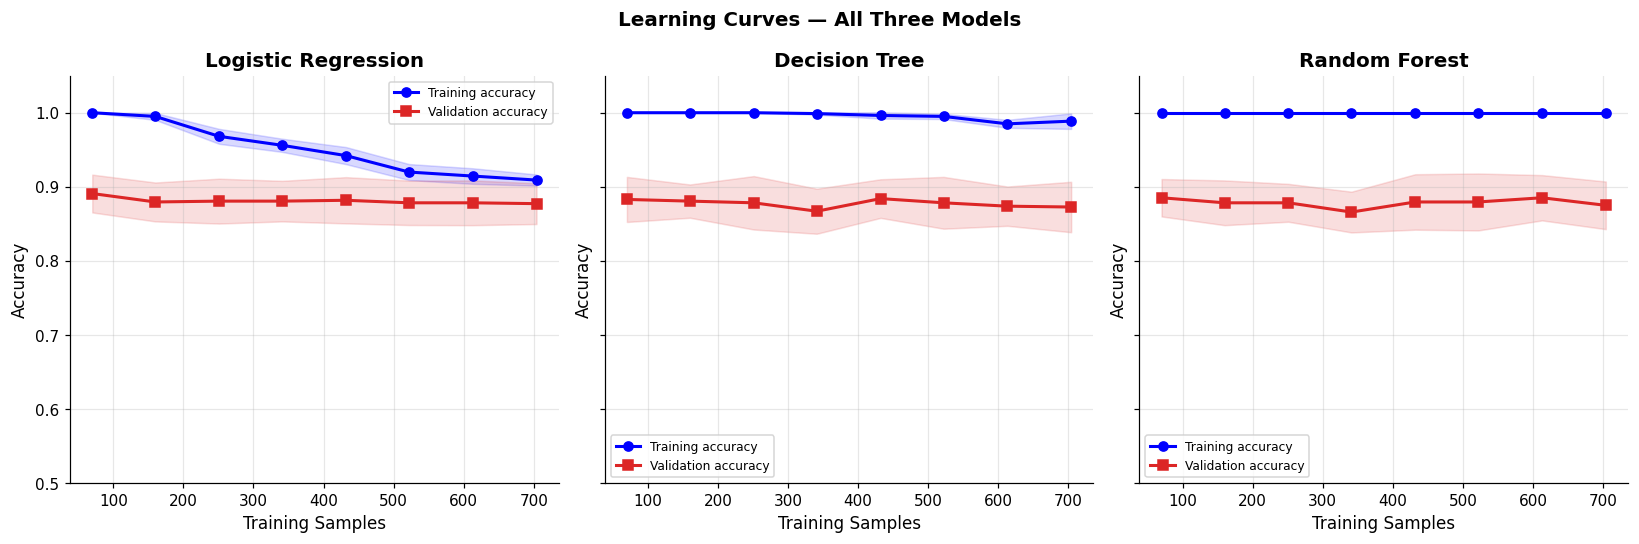

In [131]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
train_sizes = np.linspace(0.1, 1.0, 8)

for ax, (name, res) in zip(axes, results.items()):
    ts, train_sc, val_sc = learning_curve(
        res['pipe'], X_train, y_train,
        train_sizes=train_sizes, cv=cv,
        scoring='accuracy', n_jobs=-1,
    )
    train_mean = train_sc.mean(axis=1)
    train_std  = train_sc.std(axis=1)
    val_mean   = val_sc.mean(axis=1)
    val_std    = val_sc.std(axis=1)

    ax.plot(ts, train_mean, 'o-', color="blue", lw=2, label='Training accuracy')
    ax.fill_between(ts, train_mean - train_std, train_mean + train_std,
                    alpha=0.15, color="blue")
    ax.plot(ts, val_mean, 's-', color='#dc2626', lw=2, label='Validation accuracy')
    ax.fill_between(ts, val_mean - val_std, val_mean + val_std,
                    alpha=0.15, color='#dc2626')

    ax.set_title(name.replace('\n', ' '), fontweight='bold')
    ax.set_xlabel('Training Samples')
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0.5, 1.05)
    ax.legend(fontsize=8)

plt.suptitle('Learning Curves — All Three Models',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. Hyperparameter Tuning — RandomizedSearchCV

**Random Forest** had the best generalisation. We tune its hyperparameters using `RandomizedSearchCV` with 25 iterations over a defined search space. Stratified 5-fold CV ensures robust evaluation of each candidate.

In [132]:
param_dist = {
    'clf__n_estimators':      [100, 150, 200, 300],
    'clf__max_depth':         [8, 10, 12, 15, None],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf':  [1, 2, 4],
    'clf__max_features':      ['sqrt', 'log2'],
}

base_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    RandomForestClassifier(random_state=42,
                                      class_weight='balanced', n_jobs=-1)),
])

search = RandomizedSearchCV(
    base_pipe, param_dist, n_iter=25,
    cv=cv, scoring='accuracy', n_jobs=-1,
    random_state=42, verbose=0, return_train_score=True,
)
search.fit(X_train, y_train)

best_pipeline = search.best_estimator_
print('Best hyperparameters:')
for k, v in search.best_params_.items():
    print(f'  {k}: {v}')
print(f'\nBest CV accuracy : {search.best_score_:.3f}')

Best hyperparameters:
  clf__n_estimators: 150
  clf__min_samples_split: 10
  clf__min_samples_leaf: 2
  clf__max_features: log2
  clf__max_depth: 8

Best CV accuracy : 0.880


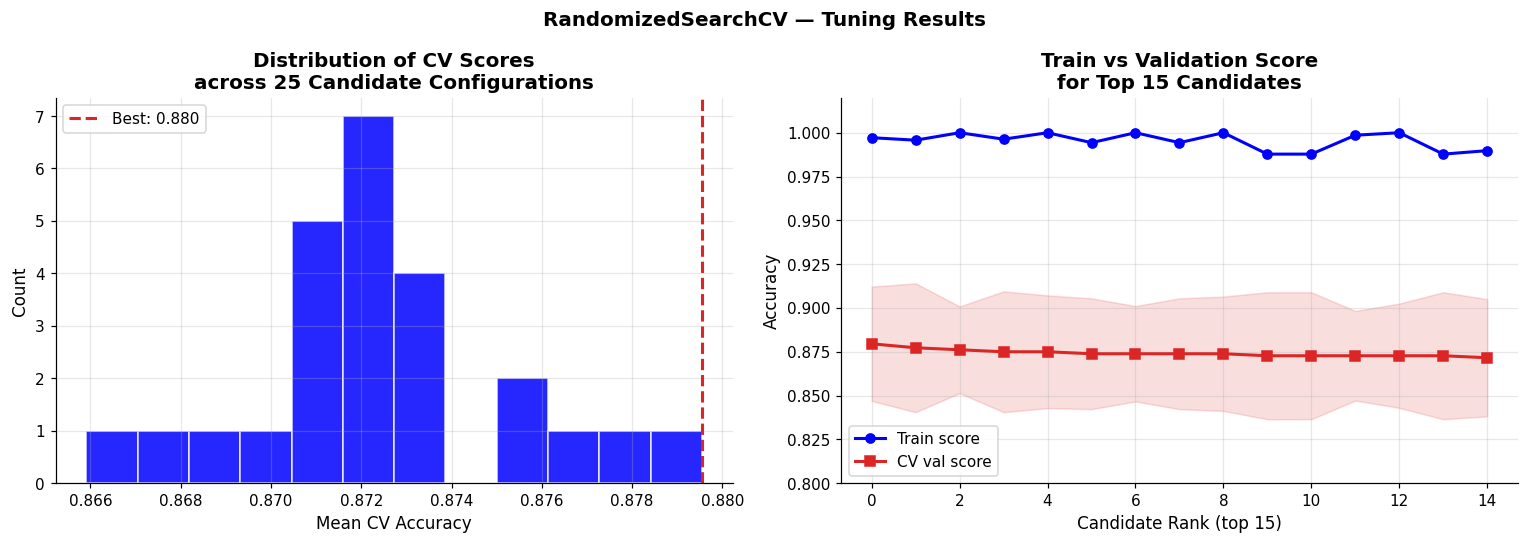

In [133]:
cv_results = pd.DataFrame(search.cv_results_)
cv_results_sorted = cv_results.sort_values('mean_test_score', ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CV score distribution across all 25 iterations
axes[0].hist(cv_results['mean_test_score'], bins=12,
             color="blue", edgecolor='white', alpha=0.85)
axes[0].axvline(search.best_score_, color='#dc2626', lw=2,
                linestyle='--', label=f'Best: {search.best_score_:.3f}')
axes[0].set_xlabel('Mean CV Accuracy')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of CV Scores\nacross 25 Candidate Configurations',
                  fontweight='bold')
axes[0].legend(fontsize=10)

# Train vs validation for top 15 candidates
idx = range(len(cv_results_sorted))
axes[1].plot(idx, cv_results_sorted['mean_train_score'].values,
             'o-', color="blue", lw=2, label='Train score')
axes[1].plot(idx, cv_results_sorted['mean_test_score'].values,
             's-', color='#dc2626', lw=2, label='CV val score')
axes[1].fill_between(
    idx,
    cv_results_sorted['mean_test_score'] - cv_results_sorted['std_test_score'],
    cv_results_sorted['mean_test_score'] + cv_results_sorted['std_test_score'],
    alpha=0.15, color='#dc2626'
)
axes[1].set_xlabel('Candidate Rank (top 15)')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Train vs Validation Score\nfor Top 15 Candidates', fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].set_ylim(0.8, 1.02)

plt.suptitle('RandomizedSearchCV — Tuning Results', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 7.1 Gradient Boosting — Alternative Model

`HistGradientBoostingClassifier` uses gradient-boosted trees with native support for missing values and better handling of small datasets through sequential error correction. Tuned with the same `RandomizedSearchCV` budget (25 iterations, 5-fold CV) as the Random Forest.

In [49]:
from sklearn.ensemble import HistGradientBoostingClassifier

gb_param_dist = {
    'clf__max_iter':          [200, 300, 400],
    'clf__max_depth':         [4, 6, 8, None],
    'clf__learning_rate':     [0.03, 0.05, 0.08, 0.12],
    'clf__min_samples_leaf':  [10, 20, 30],
    'clf__l2_regularization': [0.0, 0.1, 0.5],
}

gb_base_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    HistGradientBoostingClassifier(random_state=42)),
])

gb_search = RandomizedSearchCV(
    gb_base_pipe, gb_param_dist, n_iter=25,
    cv=cv, scoring='accuracy', n_jobs=-1,
    random_state=42, verbose=0, return_train_score=True,
)
gb_search.fit(X_train, y_train)
best_gb_pipeline = gb_search.best_estimator_

print('Best GB hyperparameters:')
for k, v in gb_search.best_params_.items():
    print(f'  {k}: {v}')
print(f'\nBest CV accuracy : {gb_search.best_score_:.3f}')

Best GB hyperparameters:
  clf__min_samples_leaf: 10
  clf__max_iter: 200
  clf__max_depth: 6
  clf__learning_rate: 0.03
  clf__l2_regularization: 0.0

Best CV accuracy : 0.886


### 7.2 Model Selection — Random Forest vs Gradient Boosting

Both tuned pipelines are evaluated on the same held-out test set. The **winner is selected by Macro F1** (ties go to Gradient Boosting). The winning `best_pipeline` is passed forward to all evaluation and save cells below.

,CV Accuracy,Test Accuracy,Macro F1
Model,,,
Random Forest,0.880,0.886,0.886
Gradient Boosting,0.886,0.873,0.873


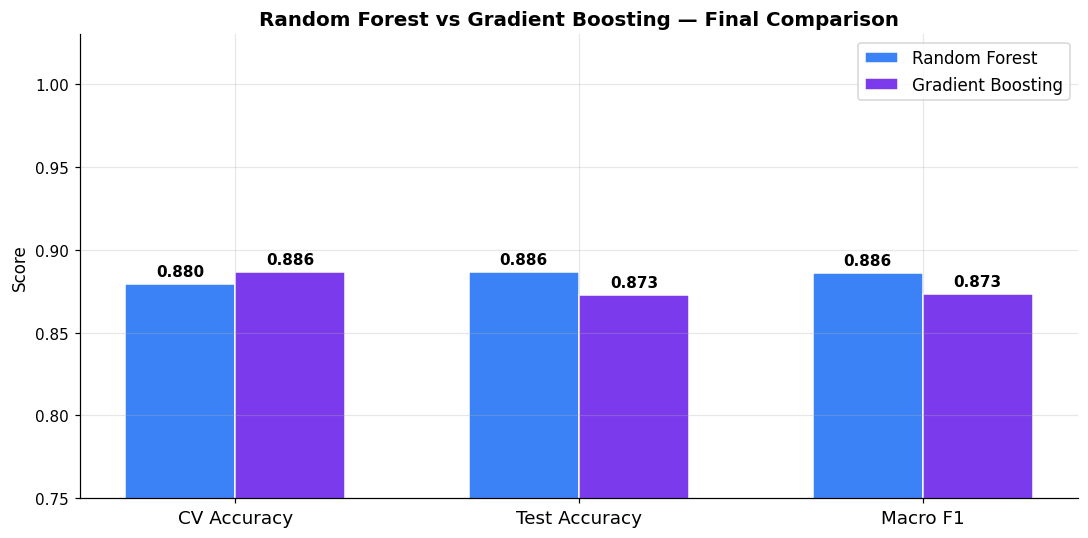


Selected model : Random Forest
Macro F1       : 0.886
Test Accuracy  : 0.886


In [50]:
from sklearn.metrics import f1_score

# Evaluate both pipelines on the held-out test set
rf_pred = best_pipeline.predict(X_test)
gb_pred = best_gb_pipeline.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)
gb_acc = accuracy_score(y_test, gb_pred)
rf_f1  = f1_score(y_test, rf_pred, average='macro')
gb_f1  = f1_score(y_test, gb_pred, average='macro')
rf_cv  = search.best_score_
gb_cv  = gb_search.best_score_

# ── Summary table ─────────────────────────────────────────
comparison = pd.DataFrame({
    'Model':         ['Random Forest', 'Gradient Boosting'],
    'CV Accuracy':   [f'{rf_cv:.3f}',  f'{gb_cv:.3f}'],
    'Test Accuracy': [f'{rf_acc:.3f}', f'{gb_acc:.3f}'],
    'Macro F1':      [f'{rf_f1:.3f}',  f'{gb_f1:.3f}'],
})
display(comparison.set_index('Model'))

# ── Bar chart ─────────────────────────────────────────────
metric_names = ['CV Accuracy', 'Test Accuracy', 'Macro F1']
rf_scores    = [rf_cv,  rf_acc,  rf_f1]
gb_scores    = [gb_cv,  gb_acc,  gb_f1]

x = np.arange(len(metric_names))
w = 0.32
fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - w/2, rf_scores, w, label='Random Forest',     color='#3b82f6', edgecolor='white')
b2 = ax.bar(x + w/2, gb_scores, w, label='Gradient Boosting', color='#7c3aed', edgecolor='white')
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.3f}', ha='center', va='bottom',
            fontsize=10, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=12)
ax.set_ylim(0.75, 1.03)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Random Forest vs Gradient Boosting — Final Comparison', fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

# ── Pick winner by Macro F1 (ties go to Gradient Boosting) ─
if gb_f1 >= rf_f1:
    best_pipeline = best_gb_pipeline
    winner_name   = 'Gradient Boosting'
else:
    winner_name   = 'Random Forest'

winner_acc = gb_acc if winner_name == 'Gradient Boosting' else rf_acc
winner_f1  = gb_f1  if winner_name == 'Gradient Boosting' else rf_f1
print(f'\nSelected model : {winner_name}')
print(f'Macro F1       : {winner_f1:.3f}')
print(f'Test Accuracy  : {winner_acc:.3f}')

---
## 8. Final Model Evaluation

The tuned pipeline is evaluated on the **held-out test set** using multiple metrics.

In [134]:
y_pred = best_pipeline.predict(X_test)
y_prob = best_pipeline.predict_proba(X_test)

print(f'Test Accuracy : {accuracy_score(y_test, y_pred):.3f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=list(LABEL_MAP.values())))

Test Accuracy : 0.886

Classification Report:
              precision    recall  f1-score   support

         Low       0.90      0.82      0.86        74
    Moderate       0.91      0.93      0.92        72
        High       0.86      0.91      0.88        74

    accuracy                           0.89       220
   macro avg       0.89      0.89      0.89       220
weighted avg       0.89      0.89      0.89       220



### 8.1 Confusion Matrix

Shows how predictions map to actual classes. The diagonal = correct predictions; off-diagonal cells = errors and which class they are confused with.

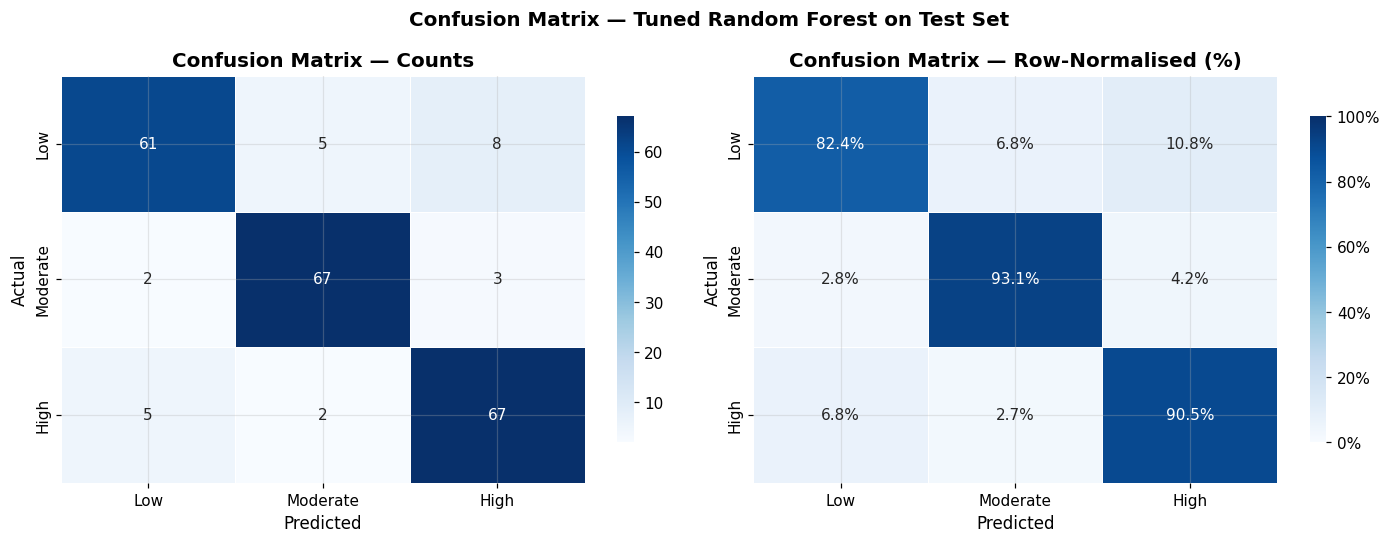

In [135]:
cm = confusion_matrix(y_test, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
class_names = list(LABEL_MAP.values())

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            ax=axes[0], linewidths=0.5, cbar_kws={'shrink': 0.8})
axes[0].set_title('Confusion Matrix — Counts', fontweight='bold')
axes[0].set_ylabel('Actual', fontsize=11)
axes[0].set_xlabel('Predicted', fontsize=11)

# Row-normalised percentages
annot = [[f'{cm_pct[i,j]:.1f}%' for j in range(3)] for i in range(3)]
sns.heatmap(cm_pct, annot=annot, fmt='', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            ax=axes[1], linewidths=0.5, cbar_kws={'shrink': 0.8, 'format': '%.0f%%'},
            vmin=0, vmax=100)
axes[1].set_title('Confusion Matrix — Row-Normalised (%)', fontweight='bold')
axes[1].set_ylabel('Actual', fontsize=11)
axes[1].set_xlabel('Predicted', fontsize=11)

plt.suptitle('Confusion Matrix — Tuned Random Forest on Test Set',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 8.2 ROC Curves — One-vs-Rest

**Receiver Operating Characteristic** curves plot the true positive rate vs false positive rate at every threshold. The **Area Under the Curve (AUC)** summarises discriminative power — 1.0 is perfect, 0.5 is random.

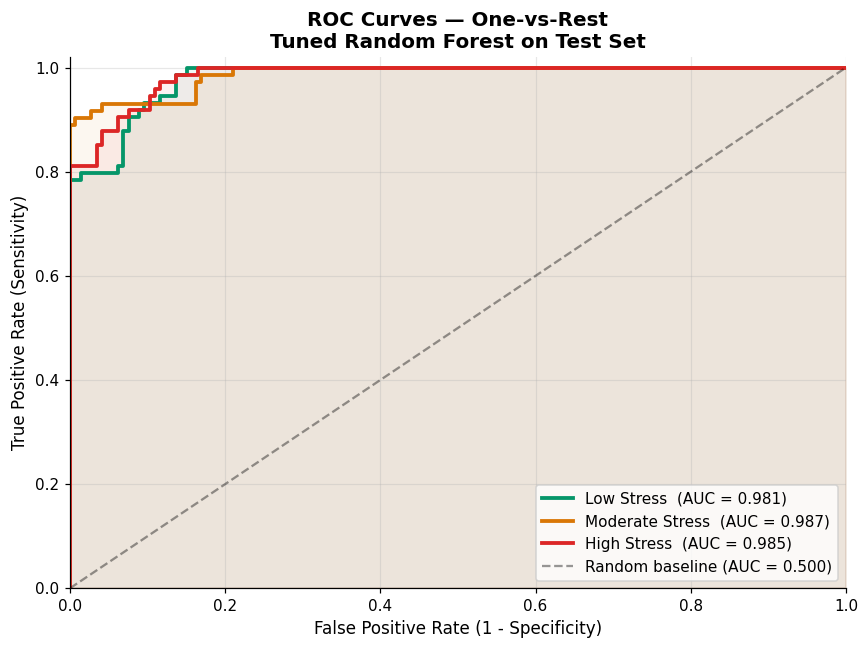

Macro-average AUC : 0.984


In [136]:
y_bin   = label_binarize(y_test, classes=[0, 1, 2])
classes = list(LABEL_MAP.values())
colors  = ['#059669', '#d97706', '#dc2626']

fig, ax = plt.subplots(figsize=(8, 6))

for i, (cls, color) in enumerate(zip(classes, colors)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2.5,
            label=f'{cls} Stress  (AUC = {roc_auc:.3f})')
    ax.fill_between(fpr, tpr, alpha=0.06, color=color)

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.4, label='Random baseline (AUC = 0.500)')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.02])
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=11)
ax.set_title('ROC Curves — One-vs-Rest\nTuned Random Forest on Test Set',
             fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

macro_auc = roc_auc_score(y_bin, y_prob, average='macro')
print(f'Macro-average AUC : {macro_auc:.3f}')

### 8.3 Precision-Recall Curves

Particularly informative for **imbalanced classes**. A high **Average Precision (AP)** score means the model retrieves most positive samples with high precision.

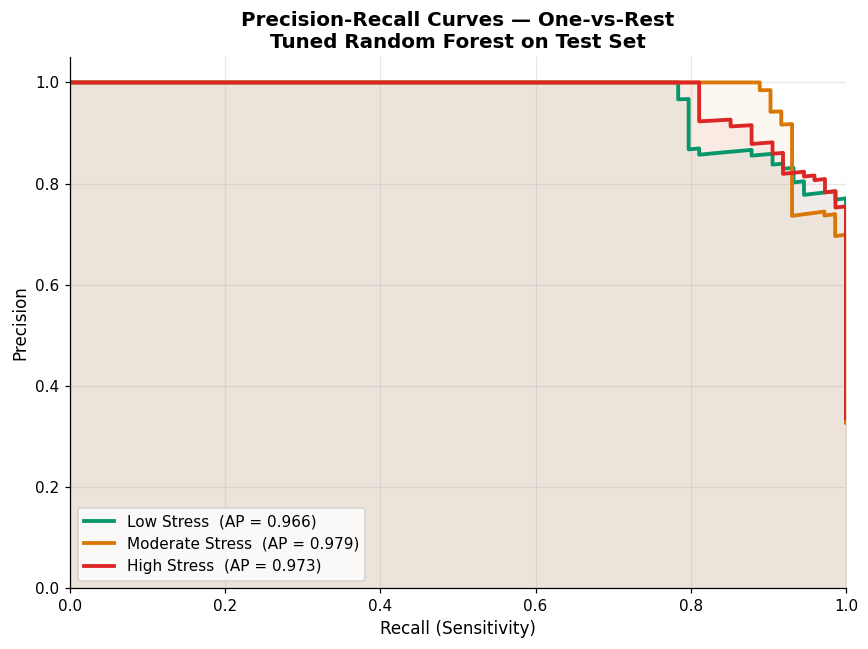

In [137]:
fig, ax = plt.subplots(figsize=(8, 6))

for i, (cls, color) in enumerate(zip(classes, colors)):
    prec, rec, _ = precision_recall_curve(y_bin[:, i], y_prob[:, i])
    ap           = average_precision_score(y_bin[:, i], y_prob[:, i])
    ax.plot(rec, prec, color=color, lw=2.5,
            label=f'{cls} Stress  (AP = {ap:.3f})')
    ax.fill_between(rec, prec, alpha=0.06, color=color)

ax.set_xlabel('Recall (Sensitivity)', fontsize=11)
ax.set_ylabel('Precision', fontsize=11)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
ax.set_title('Precision-Recall Curves — One-vs-Rest\nTuned Random Forest on Test Set',
             fontweight='bold')
ax.legend(loc='lower left', fontsize=10)
plt.tight_layout()
plt.show()

### 8.4 Feature Importance

The **Gini importance** of each feature — how much each one reduces impurity on average across all trees. Provides clinical interpretability: which factors the model weighted most.

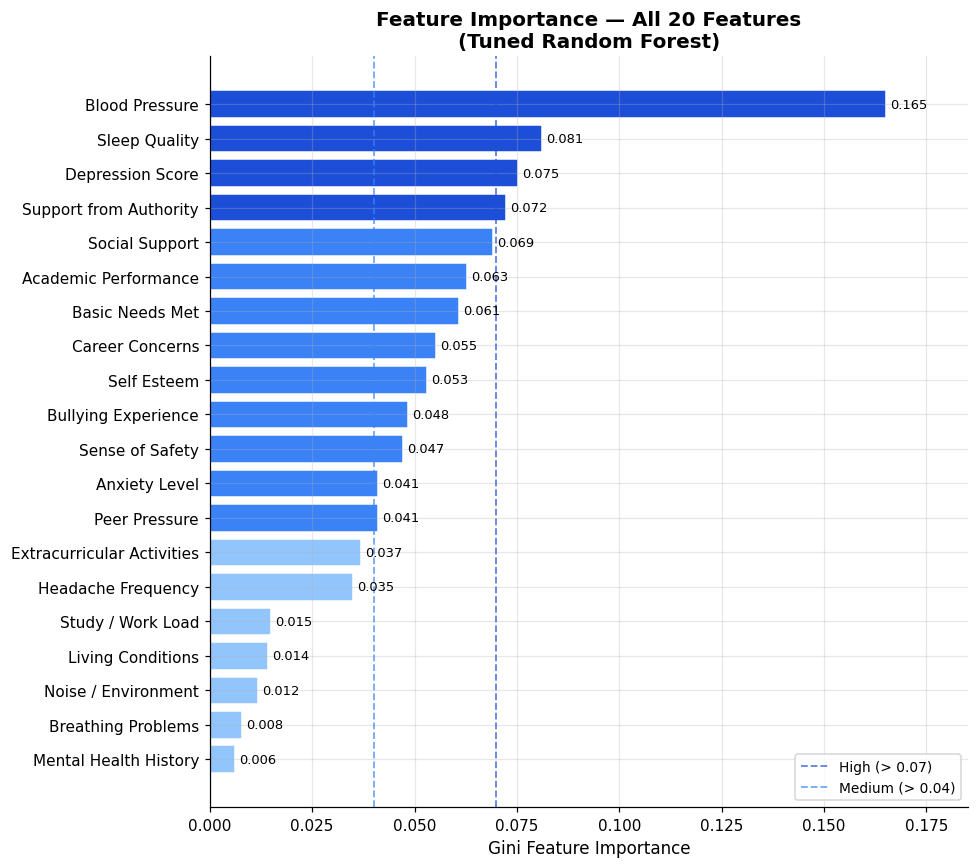

In [138]:
clf = best_pipeline.named_steps['clf']
if hasattr(clf, 'feature_importances_'):
    raw_imp = clf.feature_importances_
else:
    from sklearn.inspection import permutation_importance
    _pi     = permutation_importance(best_pipeline, X_test, y_test,
                                     n_repeats=10, random_state=42, n_jobs=-1)
    raw_imp = _pi.importances_mean.clip(0)

imp_df   = pd.DataFrame({'feature': FEATURE_COLS, 'importance': raw_imp})
imp_df['label'] = imp_df['feature'].map(FEATURE_LABELS)
imp_df   = imp_df.sort_values('importance', ascending=True)

bar_colors = [
    '#1d4ed8' if v > 0.07 else
    '#3b82f6' if v > 0.04 else
    '#93c5fd'
    for v in imp_df['importance']
]

fig, ax = plt.subplots(figsize=(9, 8))
bars = ax.barh(imp_df['label'], imp_df['importance'],
               color=bar_colors, edgecolor='white')
for bar, val in zip(bars, imp_df['importance']):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8.5)

ax.axvline(0.07, color='#1d4ed8', linestyle='--', lw=1.2, alpha=0.7, label='High (> 0.07)')
ax.axvline(0.04, color='#3b82f6', linestyle='--', lw=1.2, alpha=0.7, label='Medium (> 0.04)')
ax.set_xlabel('Feature Importance', fontsize=11)
ax.set_title(f'Feature Importance — {winner_name} (All 20 Features)', fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(0, imp_df['importance'].max() + 0.02)
plt.tight_layout()
plt.show()

### 8.5 Cumulative Feature Importance

Shows how many features are needed to explain a given fraction of the model's total decision weight — useful for **dimensionality reduction** decisions.

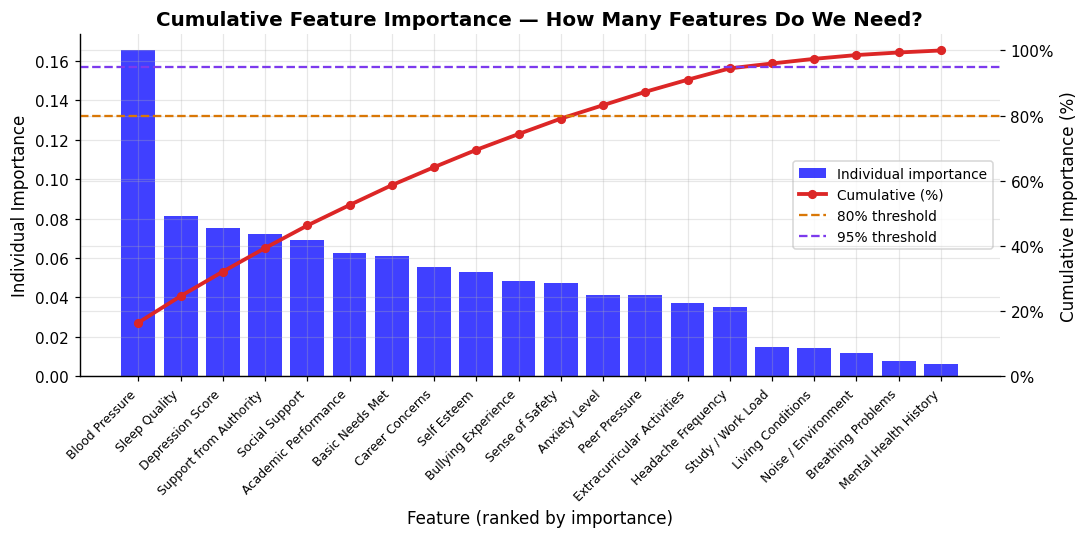

Features needed to explain 80% of importance: 12
Features needed to explain 95% of importance: 16


In [139]:
imp_sorted = imp_df.sort_values('importance', ascending=False).reset_index(drop=True)
imp_sorted['cumulative'] = imp_sorted['importance'].cumsum()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(1, len(imp_sorted)+1), imp_sorted['importance'],
       color="blue", alpha=0.75, label='Individual importance')
ax2 = ax.twinx()
ax2.plot(range(1, len(imp_sorted)+1), imp_sorted['cumulative'] * 100,
         'o-', color='#dc2626', lw=2.5, markersize=5, label='Cumulative (%)')
ax2.axhline(80, color='#d97706', linestyle='--', lw=1.5, label='80% threshold')
ax2.axhline(95, color='#7c3aed', linestyle='--', lw=1.5, label='95% threshold')
ax2.set_ylabel('Cumulative Importance (%)', fontsize=11)
ax2.set_ylim(0, 105)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())

ax.set_xticks(range(1, len(imp_sorted)+1))
ax.set_xticklabels(imp_sorted['label'], rotation=45, ha='right', fontsize=8)
ax.set_xlabel('Feature (ranked by importance)', fontsize=11)
ax.set_ylabel('Individual Importance', fontsize=11)
ax.set_title('Cumulative Feature Importance — How Many Features Do We Need?',
             fontweight='bold')

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='center right')
plt.tight_layout()
plt.show()

n80 = (imp_sorted['cumulative'] < 0.80).sum() + 1
n95 = (imp_sorted['cumulative'] < 0.95).sum() + 1
print(f'Features needed to explain 80% of importance: {n80}')
print(f'Features needed to explain 95% of importance: {n95}')

---
## 9. Save Model

The full sklearn Pipeline (scaler + tuned RF) is saved as a single `.pkl` file. The Flask backend loads it for live predictions.

In [140]:
def compute_importance(pipeline, X_ref, y_ref):
    clf = pipeline.named_steps['clf']
    if hasattr(clf, 'feature_importances_'):
        raw = clf.feature_importances_
    else:
        from sklearn.inspection import permutation_importance
        result = permutation_importance(pipeline, X_ref, y_ref,
                                        n_repeats=10, random_state=42, n_jobs=-1)
        raw = result.importances_mean.clip(0)
    total = raw.sum() if raw.sum() > 0 else 1
    return sorted([
        {'feature': feat, 'label': FEATURE_LABELS.get(feat, feat),
         'pct': round(float(v / total) * 100, 1)}
        for feat, v in zip(FEATURE_COLS, raw)
    ], key=lambda x: x['pct'], reverse=True)

os.makedirs(MODEL_DIR, exist_ok=True)
joblib.dump(best_pipeline,                                      os.path.join(MODEL_DIR, 'stress_model.pkl'))
joblib.dump(FEATURE_COLS,                                       os.path.join(MODEL_DIR, 'features.pkl'))
joblib.dump(LABEL_MAP,                                          os.path.join(MODEL_DIR, 'labels.pkl'))
joblib.dump(compute_importance(best_pipeline, X_test, y_test),  os.path.join(MODEL_DIR, 'importance.pkl'))

print(f'Saved ({winner_name}):')
for f in os.listdir(MODEL_DIR):
    size_kb = os.path.getsize(os.path.join(MODEL_DIR, f)) / 1024
    print(f'  model/{f}  ({size_kb:.1f} KB)')

Saved:
  model/features.pkl  (0.4 KB)
  model/importance.pkl  (1.1 KB)
  model/labels.pkl  (0.0 KB)
  model/stress_model.pkl  (629.7 KB)


---
## 10. Summary

Final performance summary and key findings.

In [142]:
from sklearn.metrics import precision_score, recall_score, f1_score

summary = pd.DataFrame({
    'Metric': [
        'Model', 'Test Accuracy', 'Macro Precision', 'Macro Recall',
        'Macro F1-Score', 'Macro AUC-ROC',
    ],
    'Value': [
        winner_name,
        f'{accuracy_score(y_test, y_pred):.3f}',
        f'{precision_score(y_test, y_pred, average="macro"):.3f}',
        f'{recall_score(y_test, y_pred, average="macro"):.3f}',
        f'{f1_score(y_test, y_pred, average="macro"):.3f}',
        f'{roc_auc_score(label_binarize(y_test, classes=[0,1,2]), y_prob, average="macro"):.3f}',
    ],
})

display(summary)

print(f'\nTop 5 most important features ({winner_name}):')
for i, item in enumerate(compute_importance(best_pipeline, X_test, y_test)[:5], 1):
    print(f'  {i}. {item["label"]:32s}  {item["pct"]}%')

print(f'\nPipeline: StandardScaler -> {winner_name}')
print('Next step: python app.py  (starts the Flask API)')

,Metric,Value
0,Test Accuracy,0.886
1,Macro Precision,0.887
2,Macro Recall,0.887
3,Macro F1-Score,0.886
4,Macro AUC-ROC,0.984



Top 5 most important features:
  1. Blood Pressure                    16.5%
  2. Sleep Quality                     8.1%
  3. Depression Score                  7.5%
  4. Support from Authority            7.2%
  5. Social Support                    6.9%

Pipeline: StandardScaler -> RandomForestClassifier (tuned)
Next step: python app.py  (starts the Flask API)
